# Notebook for Plotting the Angular Errors from the Output of the Angular Error Worfklow

In [18]:
import matplotlib.pyplot as plt
import pylab as pl
import h5py
from astropy.table import Table
import numpy as np

In [ ]:
path_arca_shower = "/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_aashower_mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5"
path_arca_track = "/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_jmuon_mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5"

with h5py.File(path_arca_shower, 'r') as h5_file:
    table = Table.read(h5_file)
    #print(table)
    energy = table['energy_bin_center']
    angular_error = table['median_angular_separation']
    sigma = table['sigma1_width']

table_arca_anue = Table.read(path_arca_shower)
table_arca_numu = Table.read(path_arca_track) 

In [29]:
def plot_angular_error(energy,angular_error,sigma,plt_scale,energy_low, energy_high, y_max, reco_type, detector):
    plt.figure(figsize=(10, 6))
    plt.plot(energy, angular_error, color='darkblue', label='Mean Angular Separation')
    plt.fill_between(energy, angular_error - sigma, angular_error + sigma, color='darkorange', alpha=0.3, label='1σ Band')
    plt.fill_between(energy, angular_error - 2*sigma, angular_error + 2*sigma, color='darkorange', alpha=0.1, label='2σ Band')

    if plt_scale == 'linear': 
        plt.axhline(0,color="k",ls="dashed",lw=2)

    # plt.axhline(y=0.1, color='orange', linewidth=4)  # Example of a horizontal line
    plt.xscale('log')
    plt.yscale(plt_scale)
    plt.ylim([np.min([np.nanmin(angular_error - 2*sigma -0.5),0]),y_max])
    plt.xlim([energy_low,energy_high])
    plt.xlabel(r'Reconstructed Energy $E_{reco}$ (GeV)')
    plt.ylabel(r'Angular Error $\delta\phi$ (°)')
    plt.title(f'Angular Error vs Energy ({detector} Detector {reco_type} Reco Type) ')
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()

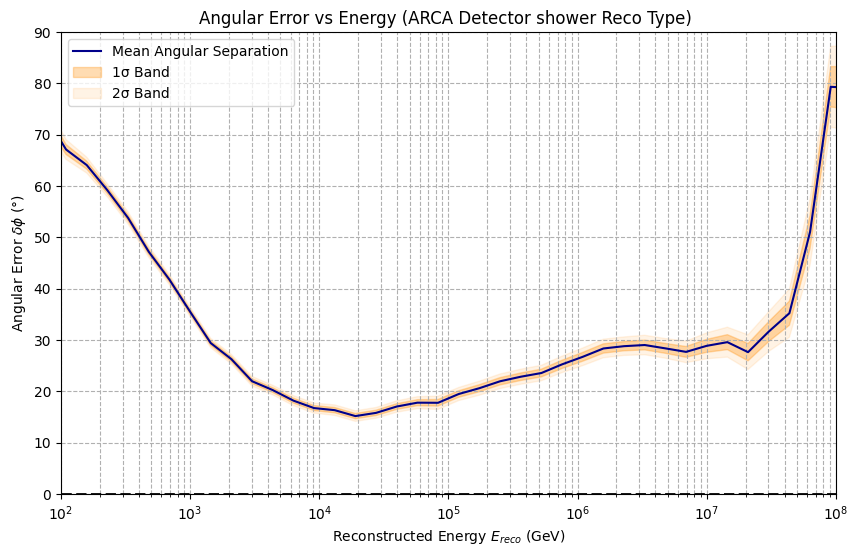

In [30]:
plt_scale = "linear"
energy_low = 1e2
energy_high = 1e8
y_max = 90
reco_type = "shower"
detector = "ARCA"
plot_angular_error(energy, angular_error, sigma, plt_scale, energy_low, energy_high, y_max, reco_type, detector)

In [52]:
import matplotlib.pyplot as plt   
def plot(table_anue,table_numu,plt_scale,energy_low, energy_high, y_max, y_min, detector):
    #plt.style.use('seaborn-white')
    # Plotting
    plt.figure(figsize=(7, 4))
    plt.plot(table_anue['energy_bin_center'], table_anue['median_angular_separation'], color='darkblue', label=r'Mean Angular Separation $\bar{\nu}_e$')
    plt.fill_between(table_anue['energy_bin_center'], table_anue['median_angular_separation'] - table_anue['sigma1_width'], table_anue['median_angular_separation'] + table_anue['sigma1_width'], color='blue', alpha=0.3, label=r'1σ Band $\bar{\nu}_e$')
    plt.fill_between(table_anue['energy_bin_center'], table_anue['median_angular_separation'] - 2*table_anue['sigma1_width'], table_anue['median_angular_separation'] + 2*table_anue['sigma1_width'], color='blue', alpha=0.1, label=r'2σ Band $\bar{\nu}_e$')

    plt.plot(table_numu['energy_bin_center'], table_numu['median_angular_separation'], color='firebrick', label=r'Mean Angular Separation $\nu_{\mu}$')
    plt.fill_between(table_numu['energy_bin_center'], table_numu['median_angular_separation'] - table_numu['sigma1_width'], table_numu['median_angular_separation'] + table_numu['sigma1_width'], color='darkorange', alpha=0.3, label=r'1σ Band $\nu_{\mu}$')
    plt.fill_between(table_numu['energy_bin_center'], table_numu['median_angular_separation'] - 2*table_numu['sigma1_width'], table_numu['median_angular_separation'] + 2*table_numu['sigma1_width'], color='darkorange', alpha=0.1, label=r'2σ Band $\nu_{\mu}$')

    if plt_scale == 'linear': 
        plt.axhline(0,color="k",ls="dashed",lw=2)

    # plt.axhline(y=0.1, color='orange', linewidth=4)  # Example of a horizontal line
    plt.xscale('log')
    plt.yscale(plt_scale)
    #y_min = np.min([np.nanmin(table_anue['median_angular_separation'] - 2*table_anue['sigma1_width'])-5e-2,np.nanmin(table_numu['median_angular_separation'] - 2*table_numu['sigma1_width']-5e-2)])
    plt.ylim([y_min,y_max])
    plt.xlim([energy_low,energy_high])
    plt.xlabel(r'Reconstructed Energy $E_{reco}$ (GeV)')
    plt.ylabel(r'Angular Error $\delta\phi$ (°)')
    plt.title(f'Angular Error vs Energy ({detector} Detector) ')
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()

    

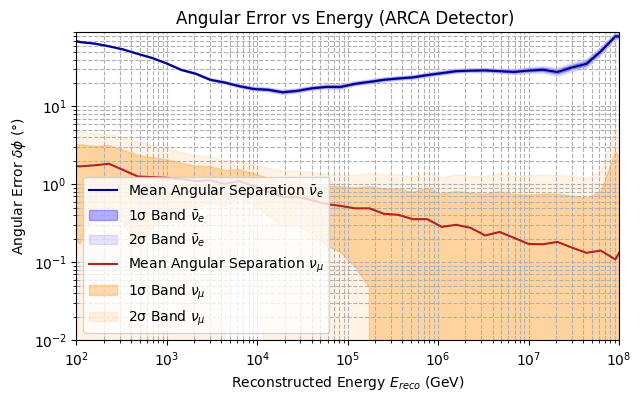

In [53]:
path_arca_shower = "/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_aashower_mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5"
path_arca_track = "/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_jmuon_mcv8.1.gsg_numu-CCHEDIS_1e2-1e8GeV.sirene.jterbr000132.hdf5"

table_arca_anue = Table.read(path_arca_shower)
table_arca_numu = Table.read(path_arca_track) 
plt_scale = "log"
energy_low = 1e2
energy_high = 1e8
y_min = 1e-2
y_max = 90
detector = "ARCA"

plot(table_arca_anue,table_arca_numu,plt_scale,energy_low, energy_high, y_max, y_min, detector)

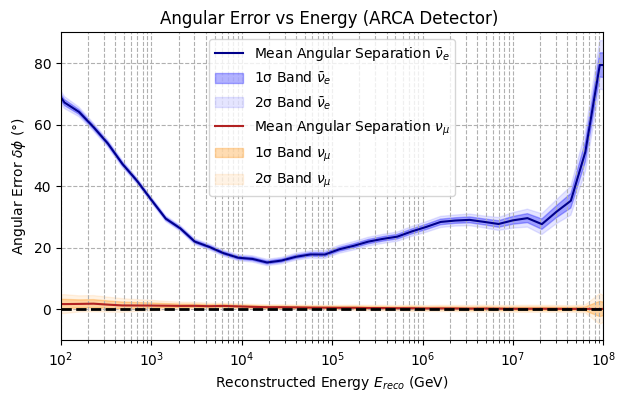

In [57]:
plt_scale = "linear"
energy_low = 1e2
energy_high = 1e8
y_min = -10
y_max = 90
detector = "ARCA"

plot(table_arca_anue,table_arca_numu,plt_scale,energy_low, energy_high, y_max, y_min, detector)

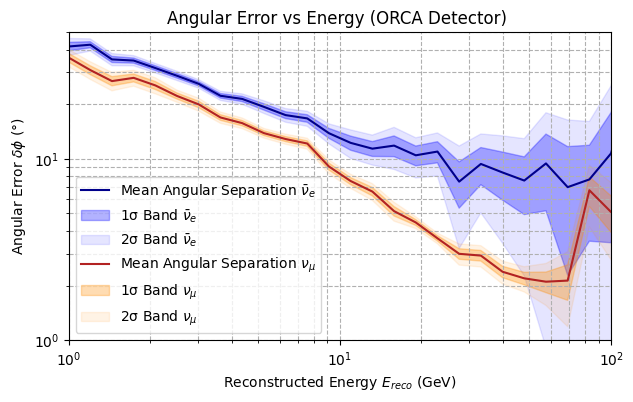

In [59]:
path_orca_shower = "/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_jshower_gsg_elec-CC_1.0-100.0GeV.hdf5"
path_orca_track = "/home/hpc/capn/capn107h/software/nextflow_output/angular_resolutions/AngularResolutionOverEnergy_jmuon_gsg_muon-CC_1.0-100.0GeV.hdf5"

table_orca_anue = Table.read(path_orca_shower)
table_orca_numu = Table.read(path_orca_track) 
plt_scale = "log"
energy_low = 1
energy_high = 1e2
y_min = 1
y_max = 50
detector = "ORCA"

plot(table_orca_anue,table_orca_numu,plt_scale,energy_low, energy_high, y_max, y_min, detector)

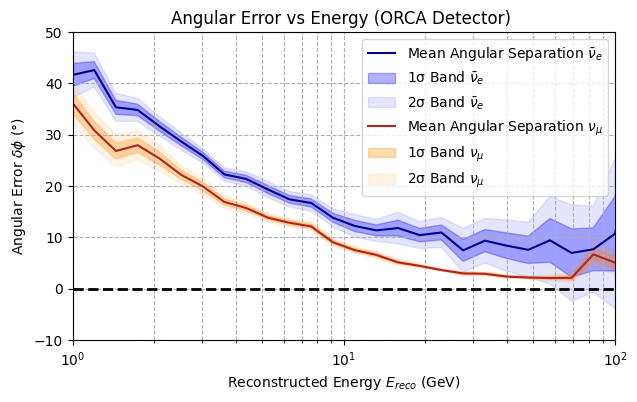

In [60]:
plt_scale = "linear"
energy_low = 1
energy_high = 1e2
y_min = -10
y_max = 50
detector = "ORCA"

plot(table_orca_anue,table_orca_numu,plt_scale,energy_low, energy_high, y_max, y_min, detector)